# CLIP and BLIP: Vision-Language Models Demo

**IUT CSE Semester 6 — CVLab**  

---

## What this notebook does

### CLIP (Contrastive Language-Image Pre-Training)
- Introduced by **Radford et al., OpenAI, 2021**
- Trained on **400 million** image-text pairs from the internet
- Core idea: images and text are embedded into the **same vector space**
- A photo of a dog and the sentence *"a photo of a dog"* end up **close** in that space
- This allows **zero-shot classification**: classify images using only text descriptions, with NO training on those classes

### BLIP (Bootstrapping Language-Image Pre-Training)
- Introduced by **Li et al., Salesforce, 2022**
- Extends CLIP with **generative** capabilities
- Can **caption** images (generate a sentence describing an image)
- Can do **Visual Question Answering** (VQA)
- Can do **image-text matching**

### Dataset: CIFAR-10
- 60,000 images across 10 classes
- Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Downloads automatically — no manual setup needed

---

## ⚠️ Before you run
1. Go to **Runtime → Change runtime type → T4 GPU** (free)
2. Then run cells one by one from top to bottom
3. First cell installs packages — takes ~2 minutes, do it once

---
# SECTION 0: Install and Import Everything
Run this cell first. It installs CLIP and BLIP from HuggingFace.

In [1]:
# ── Install required packages ──────────────────────────────────────────────
# transformers  : HuggingFace library that gives us BLIP
# ftfy          : text cleaning utility (required by CLIP)
# regex         : pattern matching (required by CLIP)
# tqdm          : progress bars

!pip install -q transformers ftfy regex tqdm

# CLIP is not on PyPI — we install directly from OpenAI's GitHub
!pip install -q git+https://github.com/openai/CLIP.git

print("\n✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done

✅ All packages installed successfully!


In [2]:
# ── Core imports ───────────────────────────────────────────────────────────
import torch
import clip                          # OpenAI CLIP
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image                # Image handling

# CIFAR-10 dataset
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# HuggingFace for BLIP
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import BlipForImageTextRetrieval

# Utilities
import warnings
warnings.filterwarnings('ignore')

# ── Device setup ───────────────────────────────────────────────────────────
# This will say 'cuda' if GPU is enabled in Colab, 'cpu' otherwise
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU")

Running on: CUDA
GPU: Tesla T4


---
# SECTION 1: Understanding CLIP

## How CLIP works (the core idea from Radford et al.)

```
Image ──► Image Encoder (ViT or ResNet) ──► image embedding vector
                                                        │
                                               cosine similarity  ──► match score
                                                        │
Text  ──► Text Encoder  (Transformer)   ──► text  embedding vector
```

Training used **contrastive loss**:  
- Matching image-text pairs → pushed **together** in embedding space  
- Non-matching pairs → pushed **apart**  

At inference, for zero-shot classification:  
1. Encode all class names as text: *"a photo of a cat"*, *"a photo of a dog"*, ...  
2. Encode the query image  
3. Find which text embedding is **closest** (highest cosine similarity) to the image embedding  
4. That class is the prediction — **no training needed on those classes!**

In [3]:
# ── Load CLIP model ────────────────────────────────────────────────────────
# Available variants: 'RN50', 'RN101', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14'
# We use ViT-B/32 — Vision Transformer, patch size 32, good balance of speed and accuracy

print("Loading CLIP model (ViT-B/32)...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()   # Set to evaluation mode (no dropout, no gradient tracking)

print(f"✅ CLIP loaded!")
print(f"   Image encoder input size : {clip_model.visual.input_resolution}x{clip_model.visual.input_resolution}")
print(f"   Embedding dimension       : {clip_model.visual.output_dim}")
print(f"   Context length (text)     : {clip_model.context_length}")

Loading CLIP model (ViT-B/32)...


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 85.9MiB/s]


✅ CLIP loaded!
   Image encoder input size : 224x224
   Embedding dimension       : 512
   Context length (text)     : 77


In [4]:
# ── Load CIFAR-10 ─────────────────────────────────────────────────────────
# CIFAR-10 has 10 classes of 32x32 images
# We use a SIMPLE transform here (just ToTensor) for downloading
# CLIP has its OWN preprocessor (clip_preprocess) we apply separately

print("Downloading CIFAR-10 (this takes ~1 minute first time)...")

# Download with basic transform first
raw_cifar10 = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,        # Use test split (10,000 images)
    download=True,
    transform=transforms.ToTensor()   # Convert PIL image to tensor
)

# Class names in CIFAR-10 (in order 0-9)
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f"✅ CIFAR-10 loaded: {len(raw_cifar10)} test images")
print(f"   Classes: {CIFAR10_CLASSES}")

100%|██████████| 170M/170M [08:24<00:00, 338kB/s]


✅ CIFAR-10 loaded: 10000 test images
   Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1.1 — CLIP Zero-Shot: Single Image Demo

Let's first understand what CLIP does on a single image before running on the full dataset.

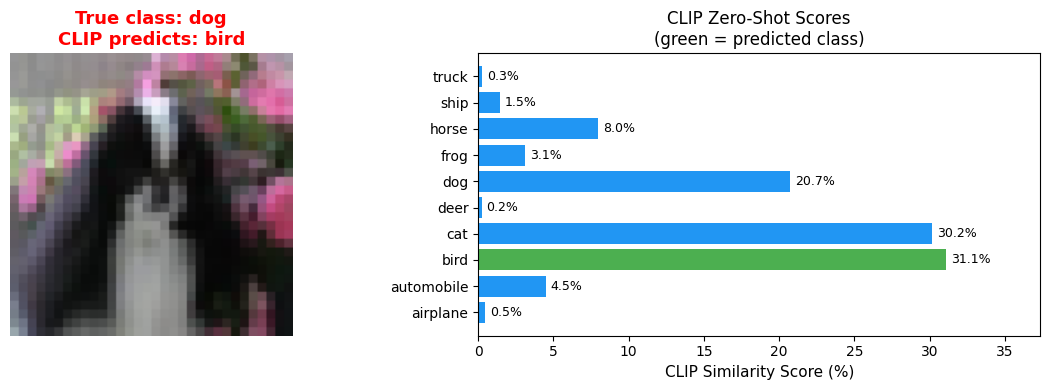


True class   : dog
CLIP predicts: bird  (❌ WRONG)
Confidence   : 31.1%


In [5]:
# ── Single image CLIP demo ─────────────────────────────────────────────────
# Pick one image from CIFAR-10 and show what CLIP thinks it is

# Pick image index 42 (arbitrary — feel free to change)
IMAGE_IDX = 42

# Get the raw PIL image and true label
# CIFAR-10 stores images as numpy arrays — convert to PIL
raw_image_np = raw_cifar10.data[IMAGE_IDX]          # numpy array HxWxC
true_label   = raw_cifar10.targets[IMAGE_IDX]       # integer 0-9
pil_image    = Image.fromarray(raw_image_np)        # PIL Image

# ── Step 1: Prepare the image for CLIP ────────────────────────────────────
# clip_preprocess resizes to 224x224, normalises pixel values
image_input = clip_preprocess(pil_image).unsqueeze(0).to(DEVICE)
# unsqueeze(0) adds batch dimension: [C,H,W] → [1,C,H,W]

# ── Step 2: Prepare text prompts ──────────────────────────────────────────
# Radford et al. showed that prompt engineering matters
# "a photo of a {class}" works better than just "{class}"
text_prompts = [f"a photo of a {c}" for c in CIFAR10_CLASSES]
text_tokens  = clip.tokenize(text_prompts).to(DEVICE)

# ── Step 3: Get embeddings ────────────────────────────────────────────────
with torch.no_grad():   # No gradients needed at inference
    image_features = clip_model.encode_image(image_input)   # shape: [1, 512]
    text_features  = clip_model.encode_text(text_tokens)    # shape: [10, 512]

# ── Step 4: Compute cosine similarities ───────────────────────────────────
# Normalise both to unit length first (standard for cosine similarity)
image_features = image_features / image_features.norm(dim=-1, keepdim=True)
text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

# Similarity: dot product of unit vectors = cosine similarity
# Scale by 100 (CLIP's temperature parameter)
similarity_scores = (100.0 * image_features @ text_features.T).softmax(dim=-1)
# Shape: [1, 10] — one probability per class

scores_np   = similarity_scores[0].cpu().numpy()
pred_idx    = scores_np.argmax()
pred_class  = CIFAR10_CLASSES[pred_idx]
true_class  = CIFAR10_CLASSES[true_label]

# ── Visualise ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: the image
ax1.imshow(pil_image.resize((128, 128), Image.NEAREST))  # Upscale for visibility
ax1.set_title(f'True class: {true_class}\nCLIP predicts: {pred_class}',
              fontsize=13, fontweight='bold',
              color='green' if pred_class == true_class else 'red')
ax1.axis('off')

# Right: bar chart of similarity scores
colors = ['#2196F3' if i != pred_idx else '#4CAF50' for i in range(10)]
bars = ax2.barh(CIFAR10_CLASSES, scores_np * 100, color=colors)
ax2.set_xlabel('CLIP Similarity Score (%)', fontsize=11)
ax2.set_title('CLIP Zero-Shot Scores\n(green = predicted class)', fontsize=12)
ax2.set_xlim(0, max(scores_np * 100) * 1.2)

# Add value labels on bars
for bar, score in zip(bars, scores_np):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{score*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('clip_single_image.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"True class   : {true_class}")
print(f"CLIP predicts: {pred_class}  ({'✅ CORRECT' if pred_class == true_class else '❌ WRONG'})")
print(f"Confidence   : {scores_np[pred_idx]*100:.1f}%")
print(f"{'='*50}")

## 1.2 — CLIP Zero-Shot: Accuracy on 500 Images

Now let's measure how well CLIP does across a larger sample — **without any training on CIFAR-10**.  
We use 500 images (50 per class) so it runs fast even on free Colab.

Running CLIP zero-shot on 500 images...

  CLIP Zero-Shot Accuracy: 90.6%  (453/500)
  (No fine-tuning — straight from pre-training!)


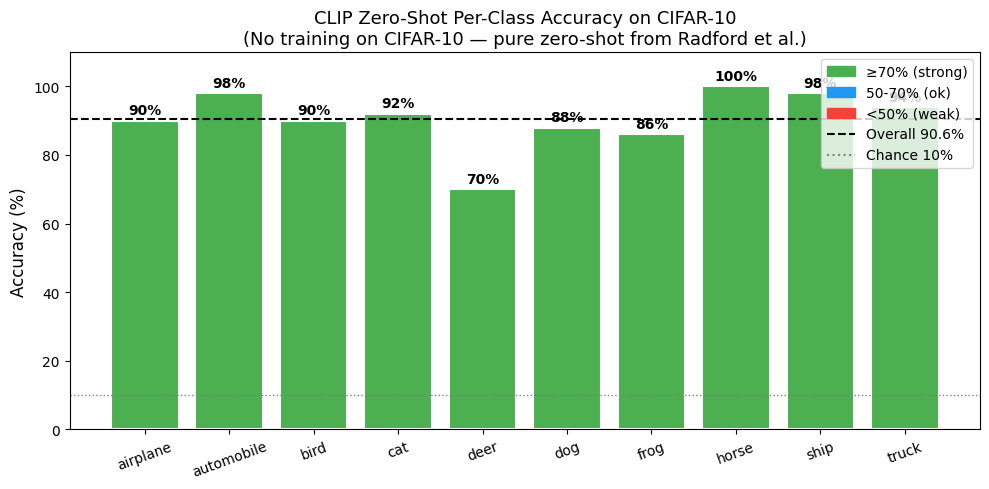

In [6]:
# ── CLIP zero-shot accuracy on 500 images ─────────────────────────────────

# ── Pre-compute text embeddings (do this ONCE, reuse for all images) ──────
text_prompts = [f"a photo of a {c}" for c in CIFAR10_CLASSES]
text_tokens  = clip.tokenize(text_prompts).to(DEVICE)

with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# ── Select 50 images per class (500 total) ────────────────────────────────
# Build index list: 50 from each of the 10 classes
indices_per_class = {c: [] for c in range(10)}
for idx, (_, label) in enumerate(raw_cifar10):
    if len(indices_per_class[label]) < 50:
        indices_per_class[label].append(idx)
    if all(len(v) == 50 for v in indices_per_class.values()):
        break

selected_indices = [idx for idxs in indices_per_class.values() for idx in idxs]
subset = Subset(raw_cifar10, selected_indices)

# ── Run CLIP on each image ─────────────────────────────────────────────────
correct        = 0
total          = 0
per_class_correct = {c: 0 for c in CIFAR10_CLASSES}
per_class_total   = {c: 0 for c in CIFAR10_CLASSES}

print("Running CLIP zero-shot on 500 images...")

for img_tensor, label in subset:
    # Convert tensor back to PIL for clip_preprocess
    pil_img  = transforms.ToPILImage()(img_tensor)
    img_input = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        img_feat = clip_model.encode_image(img_input)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

    # Similarity scores
    sims = (100.0 * img_feat @ text_features.T).softmax(dim=-1)
    pred = sims[0].argmax().item()

    class_name = CIFAR10_CLASSES[label]
    per_class_total[class_name]   += 1
    if pred == label:
        correct += 1
        per_class_correct[class_name] += 1
    total += 1

overall_acc = correct / total * 100
print(f"\n{'='*50}")
print(f"  CLIP Zero-Shot Accuracy: {overall_acc:.1f}%  ({correct}/{total})")
print(f"  (No fine-tuning — straight from pre-training!)")
print(f"{'='*50}")

# ── Per-class accuracy bar chart ───────────────────────────────────────────
per_class_acc = [
    per_class_correct[c] / per_class_total[c] * 100
    for c in CIFAR10_CLASSES
]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#4CAF50' if a >= 70 else '#2196F3' if a >= 50 else '#F44336'
           for a in per_class_acc]
bars    = ax.bar(CIFAR10_CLASSES, per_class_acc, color=colors, edgecolor='white', linewidth=1.5)

ax.axhline(y=overall_acc, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall: {overall_acc:.1f}%')
ax.axhline(y=10, color='gray', linestyle=':', linewidth=1,
           label='Random chance (10%)')

# Value labels
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('CLIP Zero-Shot Per-Class Accuracy on CIFAR-10\n'
             '(No training on CIFAR-10 — pure zero-shot from Radford et al.)',
             fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=20)

# Legend for colors
green  = mpatches.Patch(color='#4CAF50', label='≥70% (strong)')
blue   = mpatches.Patch(color='#2196F3', label='50-70% (ok)')
red    = mpatches.Patch(color='#F44336', label='<50% (weak)')
ax.legend(handles=[green, blue, red,
          plt.Line2D([0],[0], color='black', linestyle='--', label=f'Overall {overall_acc:.1f}%'),
          plt.Line2D([0],[0], color='gray',  linestyle=':',  label='Chance 10%')],
          fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('clip_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 — Visualise the CLIP Embedding Space

CLIP maps every image and text into a 512-dimensional vector.  
We use **t-SNE** to project those 512 dimensions down to 2D so we can *see* the embedding space.  
Images of the same class should cluster together.

Extracting CLIP embeddings for 500 images...
Running t-SNE (projects 512D → 2D for visualisation)...


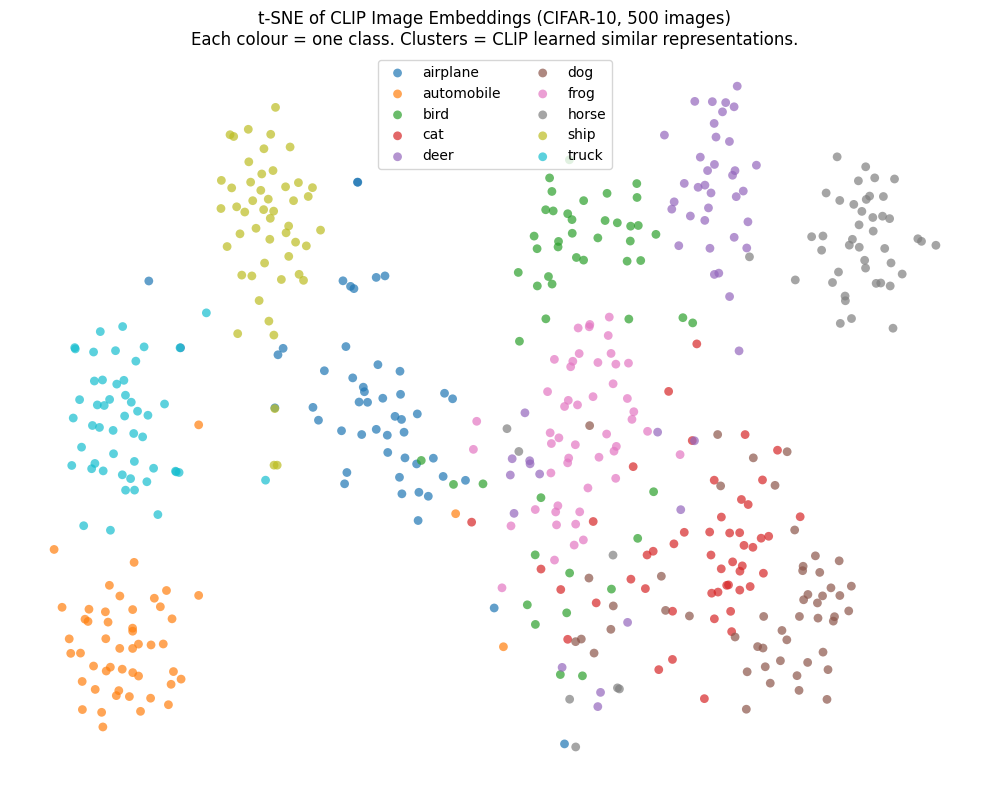


→ Well-separated clusters = CLIP has learned good visual representations
→ Overlapping clusters = those classes are visually similar (e.g. cat/dog)


In [7]:
# ── t-SNE visualisation of CLIP embeddings ─────────────────────────────────
from sklearn.manifold import TSNE

print("Extracting CLIP embeddings for 500 images...")

all_embeddings = []
all_labels     = []

for img_tensor, label in subset:
    pil_img   = transforms.ToPILImage()(img_tensor)
    img_input = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feat = clip_model.encode_image(img_input)
        feat = feat / feat.norm(dim=-1, keepdim=True)

    all_embeddings.append(feat.cpu().numpy()[0])
    all_labels.append(label)

embeddings_np = np.array(all_embeddings)  # shape: [500, 512]
labels_np     = np.array(all_labels)

print("Running t-SNE (projects 512D → 2D for visualisation)...")
tsne      = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
emb_2d    = tsne.fit_transform(embeddings_np)   # shape: [500, 2]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors_tsne = plt.cm.tab10(np.linspace(0, 1, 10))

for class_idx, class_name in enumerate(CIFAR10_CLASSES):
    mask = labels_np == class_idx
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[colors_tsne[class_idx]],
               label=class_name, alpha=0.7, s=40, edgecolors='none')

ax.set_title('t-SNE of CLIP Image Embeddings (CIFAR-10, 500 images)\n'
             'Each colour = one class. Clusters = CLIP learned similar representations.',
             fontsize=12)
ax.legend(fontsize=10, loc='best', ncol=2)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.axis('off')

plt.tight_layout()
plt.savefig('clip_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ Well-separated clusters = CLIP has learned good visual representations")
print("→ Overlapping clusters = those classes are visually similar (e.g. cat/dog)")

## 1.4 — Image-to-Image and Text-to-Image Similarity

CLIP can also compare images to each other, or retrieve the most similar image for a text query.

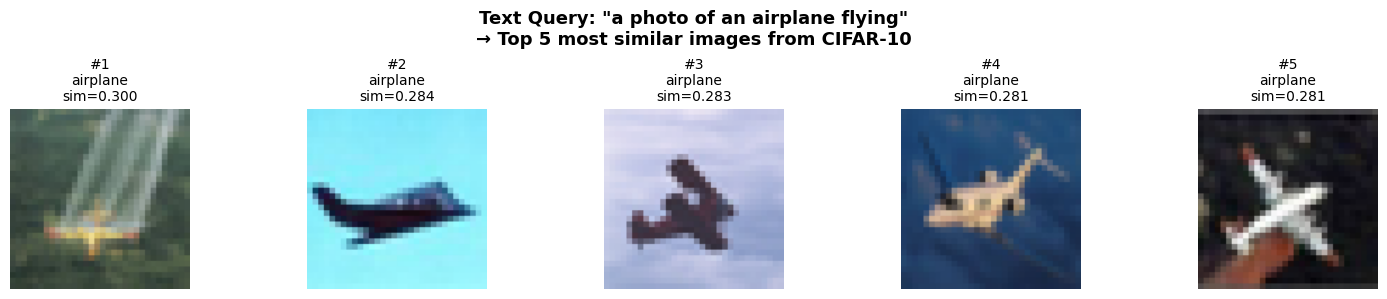


→ CLIP retrieved the most visually-semantically matching images for the text query
→ This is how CLIP enables cross-modal search (text ↔ image)


In [8]:
# ── Text-to-image retrieval with CLIP ─────────────────────────────────────
# Given a text query, find the most similar images from our 500-image pool

QUERY_TEXT = "a photo of an airplane flying"   # ← change this to anything you want!

# Encode the query
query_tokens   = clip.tokenize([QUERY_TEXT]).to(DEVICE)
with torch.no_grad():
    query_feat = clip_model.encode_text(query_tokens)
    query_feat = query_feat / query_feat.norm(dim=-1, keepdim=True)

# Compute similarity of query text against all 500 image embeddings
# embeddings_np already computed above
emb_tensor  = torch.tensor(embeddings_np).to(DEVICE)
sims        = (query_feat @ emb_tensor.T)[0].cpu().numpy()  # [500]
top5_idx    = sims.argsort()[::-1][:5]   # Top 5 most similar

# Show results
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Text Query: "{QUERY_TEXT}"\n→ Top 5 most similar images from CIFAR-10',
             fontsize=13, fontweight='bold')

subset_list = list(subset)
for rank, (ax, idx) in enumerate(zip(axes, top5_idx)):
    img_tensor, label = subset_list[idx]
    pil_img = transforms.ToPILImage()(img_tensor)
    ax.imshow(pil_img.resize((96, 96), Image.NEAREST))
    ax.set_title(f'#{rank+1}\n{CIFAR10_CLASSES[label]}\nsim={sims[idx]:.3f}',
                 fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('clip_text_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ CLIP retrieved the most visually-semantically matching images for the text query")
print("→ This is how CLIP enables cross-modal search (text ↔ image)")

---
# SECTION 2: Understanding BLIP

## How BLIP differs from CLIP

| Feature | CLIP | BLIP |
|---------|------|------|
| Architecture | Dual encoder | Encoder + Decoder |
| Can generate text? | ❌ No | ✅ Yes |
| Zero-shot classification | ✅ Yes | ✅ Yes |
| Image captioning | ❌ No | ✅ Yes |
| Visual QA | Limited | ✅ Yes |
| Training data | 400M image-text pairs | 129M image-text pairs + bootstrapping |

**Key innovation in BLIP:** *Bootstrapping* — BLIP generates its own captions for noisy web data and filters them using an Image-Text Matching (ITM) module. This cleans the training data automatically.

In [9]:
# ── Load BLIP for Image Captioning ────────────────────────────────────────
# We use the base model — smaller, faster, works well on free Colab GPU
# 'Salesforce/blip-image-captioning-base'

BLIP_MODEL_ID = "Salesforce/blip-image-captioning-base"

print(f"Loading BLIP captioning model from HuggingFace...")
print("(First time downloads ~900MB — subsequent runs use cache)")

blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_ID)
blip_caption_model = BlipForConditionalGeneration.from_pretrained(
    BLIP_MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
).to(DEVICE)
blip_caption_model.eval()

print("✅ BLIP captioning model loaded!")

Loading BLIP captioning model from HuggingFace...
(First time downloads ~900MB — subsequent runs use cache)


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

✅ BLIP captioning model loaded!


## 2.1 — BLIP Image Captioning: What does BLIP *say* about CIFAR-10 images?

Generating captions for 20 images (takes ~30 seconds)...
  5/20 done...
  10/20 done...
  15/20 done...
  20/20 done...
✅ Captions generated!


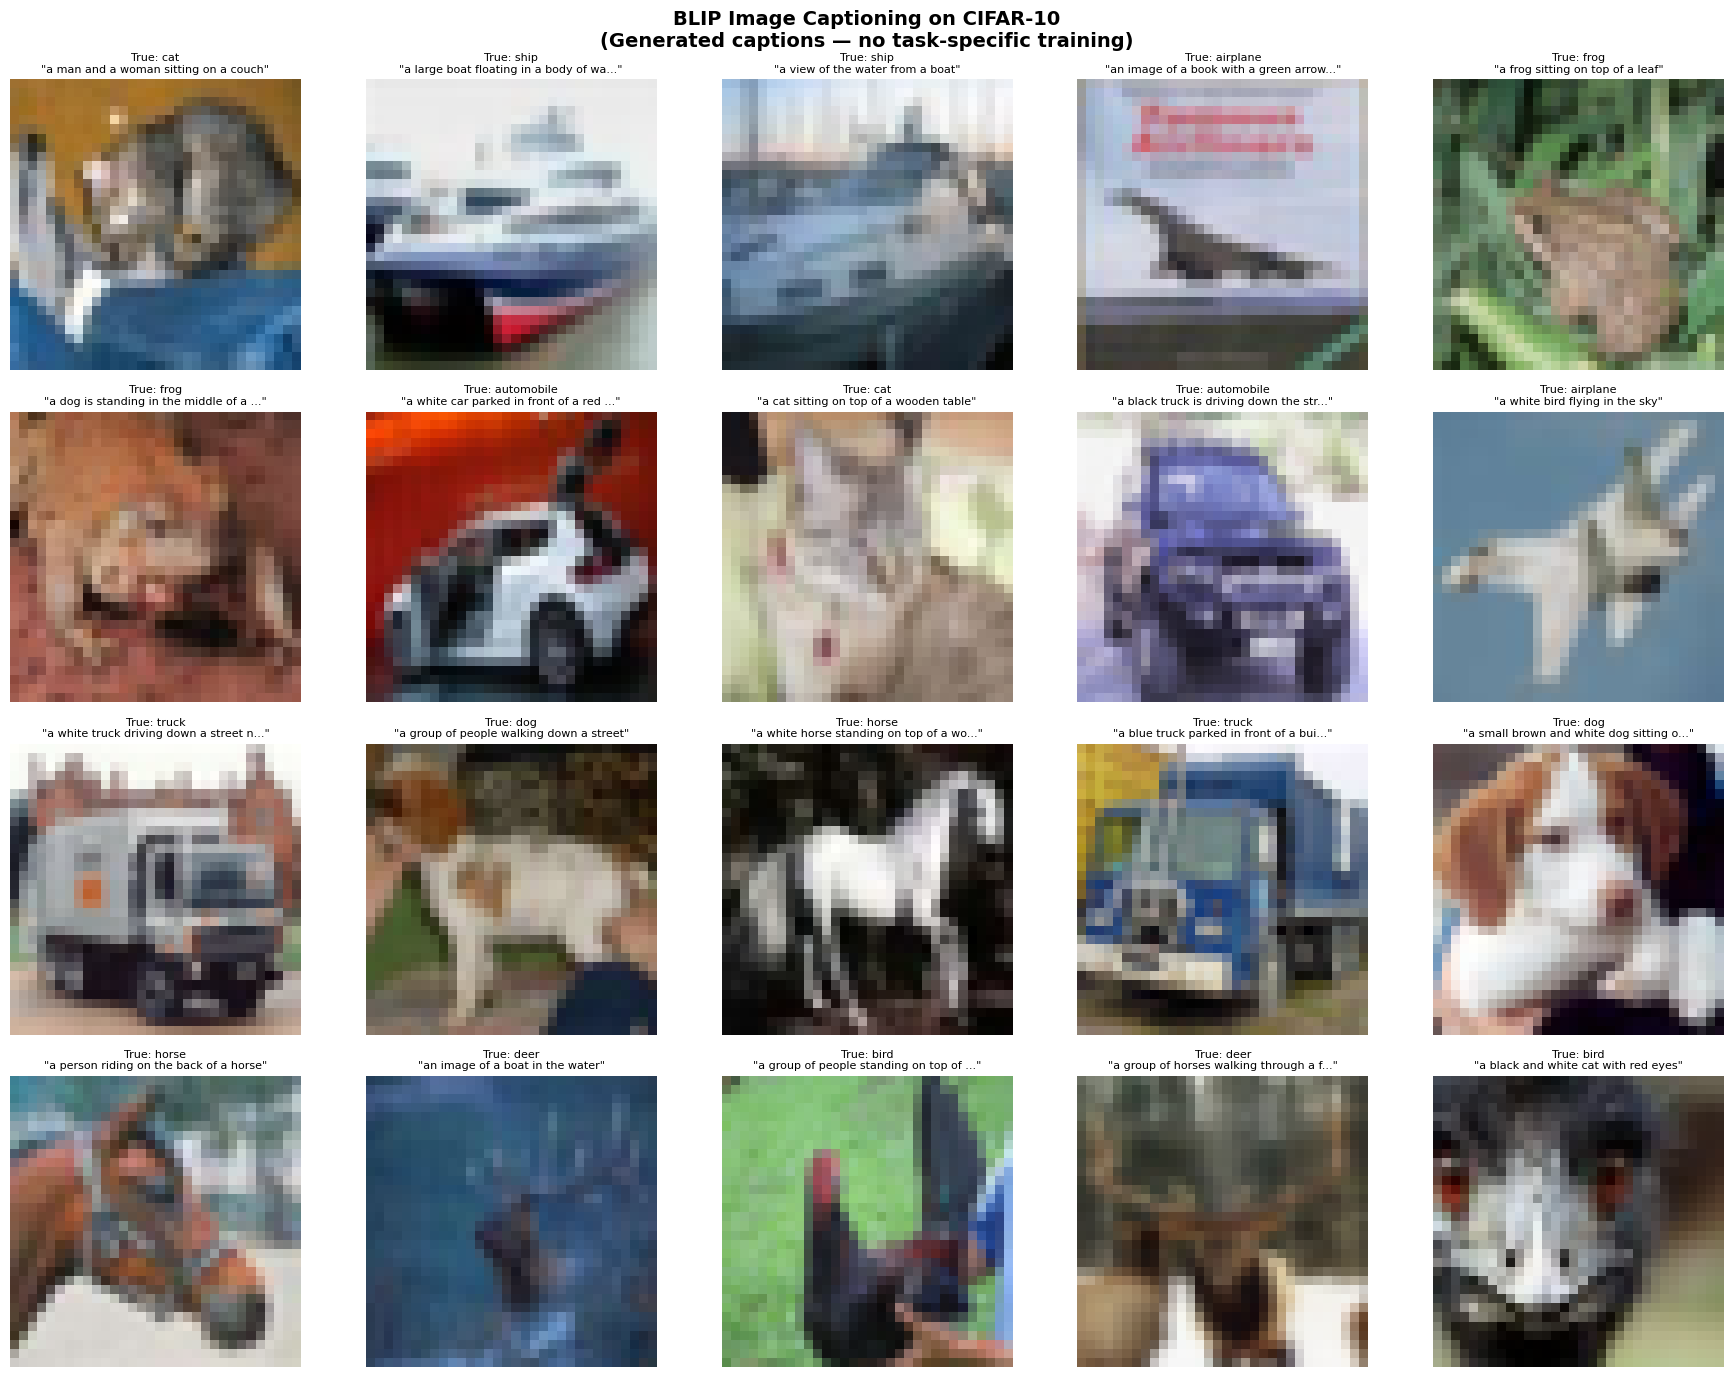


--- BLIP Generated Captions ---
  [cat         ] → a man and a woman sitting on a couch
  [ship        ] → a large boat floating in a body of water
  [ship        ] → a view of the water from a boat
  [airplane    ] → an image of a book with a green arrow on it
  [frog        ] → a frog sitting on top of a leaf
  [frog        ] → a dog is standing in the middle of a room
  [automobile  ] → a white car parked in front of a red wall
  [cat         ] → a cat sitting on top of a wooden table
  [automobile  ] → a black truck is driving down the street
  [airplane    ] → a white bird flying in the sky
  [truck       ] → a white truck driving down a street next to a building
  [dog         ] → a group of people walking down a street
  [horse       ] → a white horse standing on top of a wooden floor
  [truck       ] → a blue truck parked in front of a building
  [dog         ] → a small brown and white dog sitting on a person ' s lap
  [horse       ] → a person riding on the back of a horse
 

In [10]:
# ── BLIP captioning on a grid of CIFAR-10 images ─────────────────────────
# We pick 2 images from each class (20 total) and show BLIP's captions

def blip_caption(pil_image):
    """Generate a caption for a PIL image using BLIP."""
    # Preprocess: resize, normalise
    inputs = blip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(DEVICE, torch.float16 if DEVICE == 'cuda' else torch.float32)

    # Generate caption (beam search, max 30 tokens)
    with torch.no_grad():
        output_ids = blip_caption_model.generate(
            **inputs,
            max_new_tokens=30,
            num_beams=4,          # Beam search width
            early_stopping=True
        )

    # Decode token IDs back to text
    caption = blip_processor.decode(output_ids[0], skip_special_tokens=True)
    return caption

# Select 2 images per class
demo_images  = []
demo_labels  = []
seen_classes = {c: 0 for c in range(10)}

for img_tensor, label in raw_cifar10:
    if seen_classes[label] < 2:
        demo_images.append(img_tensor)
        demo_labels.append(label)
        seen_classes[label] += 1
    if all(v == 2 for v in seen_classes.values()):
        break

# Generate captions
print("Generating captions for 20 images (takes ~30 seconds)...")
captions = []
for i, img_tensor in enumerate(demo_images):
    pil_img = transforms.ToPILImage()(img_tensor)
    # CIFAR-10 is 32x32 — upscale to 128x128 for better BLIP results
    pil_img_large = pil_img.resize((128, 128), Image.BILINEAR)
    cap = blip_caption(pil_img_large)
    captions.append(cap)
    if (i+1) % 5 == 0:
        print(f"  {i+1}/20 done...")

print("✅ Captions generated!")

# ── Display grid ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('BLIP Image Captioning on CIFAR-10\n'
             '(Generated captions — no task-specific training)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    pil_img = transforms.ToPILImage()(demo_images[i])
    ax.imshow(pil_img.resize((96, 96), Image.NEAREST))
    true_cls = CIFAR10_CLASSES[demo_labels[i]]
    cap = captions[i]
    # Wrap caption text for display
    cap_short = cap if len(cap) < 40 else cap[:37] + '...'
    ax.set_title(f'True: {true_cls}\n"{cap_short}"',
                 fontsize=8, wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.savefig('blip_captions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print captions neatly
print("\n--- BLIP Generated Captions ---")
for i, (label, cap) in enumerate(zip(demo_labels, captions)):
    print(f"  [{CIFAR10_CLASSES[label]:12s}] → {cap}")

## 2.2 — BLIP Image-Text Matching

BLIP can also score how well a text description matches an image.  
Score close to 1.0 = strong match. Score close to 0.0 = poor match.

In [11]:
# ── Load BLIP Image-Text Matching model ───────────────────────────────────
print("Loading BLIP ITM model...")
blip_itm_model = BlipForImageTextRetrieval.from_pretrained(
    "Salesforce/blip-itm-base-coco",
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
).to(DEVICE)
blip_itm_model.eval()
print("✅ BLIP ITM model loaded!")

Loading BLIP ITM model...


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  895MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

✅ BLIP ITM model loaded!


model.safetensors: reconstructing file:   0%|          |  0.00B /  895MB            

Scoring image-text pairs with BLIP ITM...



model.safetensors: downloading bytes:           |  0.00B            

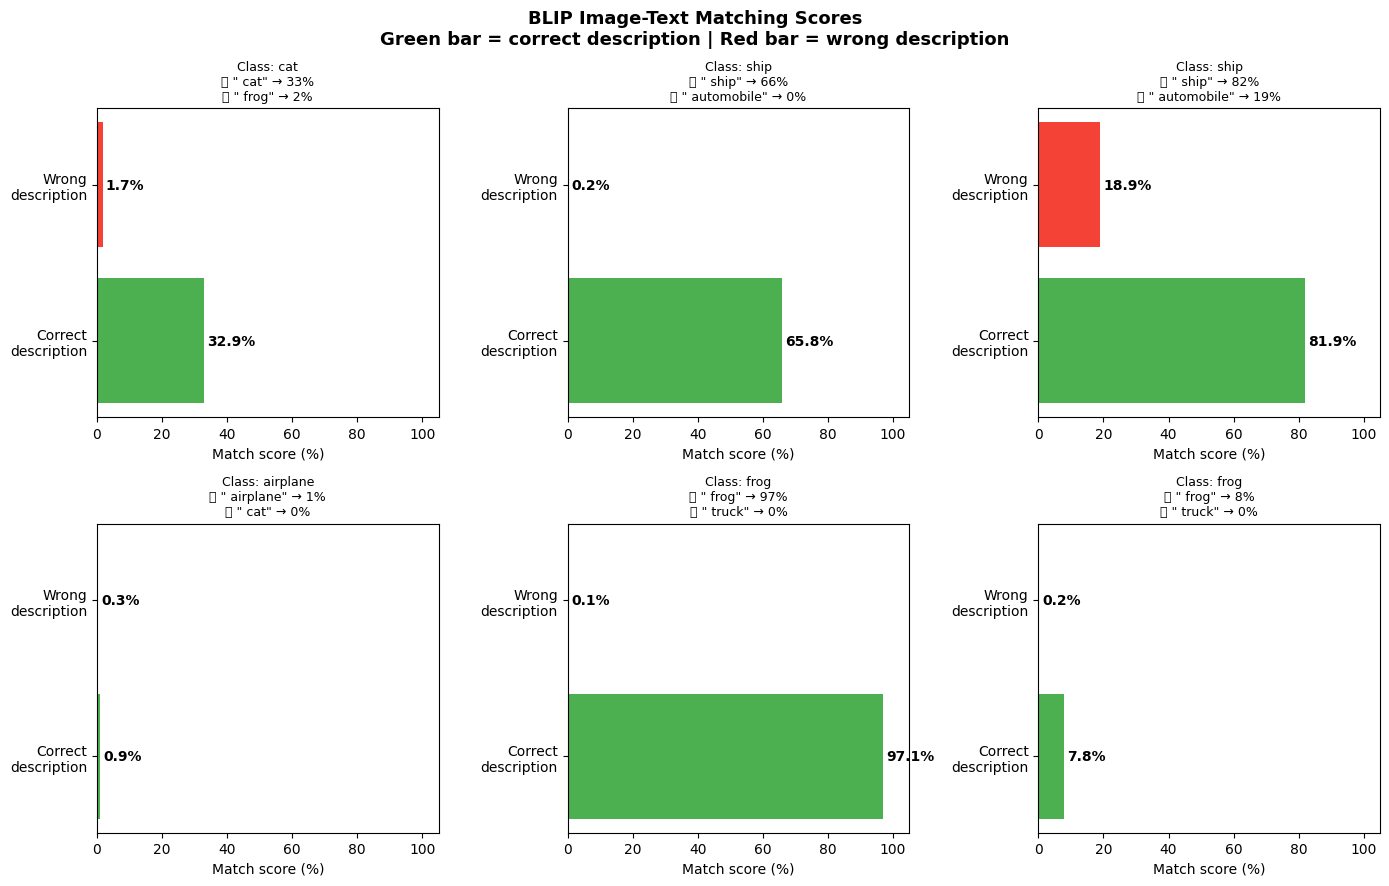


→ High correct score + low wrong score = BLIP understands image content


In [12]:
# ── BLIP ITM: Score image-text pairs ──────────────────────────────────────

def blip_itm_score(pil_image, text):
    """Returns match probability (0 to 1) for an image-text pair."""
    inputs = blip_processor(
        images=pil_image,
        text=text,
        return_tensors="pt"
    ).to(DEVICE, torch.float16 if DEVICE == 'cuda' else torch.float32)

    with torch.no_grad():
        output = blip_itm_model(**inputs, use_itm_head=True)
        # output.itm_score: [batch, 2] where dim 1 = [no_match, match]
        score  = torch.nn.functional.softmax(output.itm_score, dim=1)
        match_prob = score[0][1].item()  # probability of match

    return match_prob

# Pick 6 images from different classes for the demo
demo_idx  = [0, 1, 2, 3, 4, 5]  # indices into demo_images list

# For each image, score against CORRECT and WRONG text descriptions
print("Scoring image-text pairs with BLIP ITM...\n")

results = []
for idx in demo_idx:
    img_tensor = demo_images[idx]
    true_class = CIFAR10_CLASSES[demo_labels[idx]]
    pil_img    = transforms.ToPILImage()(img_tensor).resize((128, 128), Image.BILINEAR)

    correct_text = f"a photo of a {true_class}"
    wrong_class  = CIFAR10_CLASSES[(demo_labels[idx] + 3) % 10]  # a different class
    wrong_text   = f"a photo of a {wrong_class}"

    score_correct = blip_itm_score(pil_img, correct_text)
    score_wrong   = blip_itm_score(pil_img, wrong_text)

    results.append((pil_img, true_class, correct_text, wrong_text,
                    score_correct, score_wrong))

# ── Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('BLIP Image-Text Matching Scores\n'
             'Green bar = correct description | Red bar = wrong description',
             fontsize=13, fontweight='bold')

for ax, (pil_img, true_cls, ctxt, wtxt, sc, sw) in zip(axes.flat, results):
    # Mini axes layout: image on left, bars on right
    # We'll put image as inset
    ax.barh(['Correct\ndescription', 'Wrong\ndescription'],
            [sc * 100, sw * 100],
            color=['#4CAF50', '#F44336'])
    ax.set_xlim(0, 105)
    ax.set_xlabel('Match score (%)')
    ax.set_title(f'Class: {true_cls}\n'
                 f'✅ "{ctxt[12:]}" → {sc*100:.0f}%\n'
                 f'❌ "{wtxt[12:]}" → {sw*100:.0f}%',
                 fontsize=9)

    for i, score in enumerate([sc * 100, sw * 100]):
        ax.text(score + 1, i, f'{score:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('blip_itm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ High correct score + low wrong score = BLIP understands image content")

## 2.3 — BLIP ITM: Raw Scores (Text Table for Report)

In [13]:
# ── Print raw ITM scores as text (for the report) ───────────────────────────────
print(f"{'Class':<12} {'Correct text':<28} {'Score':>7}   {'Wrong text':<28} {'Score':>7}")
print("-" * 90)
for pil_img, true_cls, ctxt, wtxt, sc, sw in results:
    print(f"{true_cls:<12} {ctxt:<28} {sc*100:>6.1f}%   {wtxt:<28} {sw*100:>6.1f}%")

avg_correct = sum(r[4] for r in results) / len(results) * 100
avg_wrong   = sum(r[5] for r in results) / len(results) * 100
print("-" * 90)
print(f"{'AVERAGE':<12} {'':<28} {avg_correct:>6.1f}%   {'':<28} {avg_wrong:>6.1f}%")

Class        Correct text                   Score   Wrong text                     Score
------------------------------------------------------------------------------------------
cat          a photo of a cat               32.9%   a photo of a frog               1.7%
ship         a photo of a ship              65.8%   a photo of a automobile         0.2%
ship         a photo of a ship              81.9%   a photo of a automobile        18.9%
airplane     a photo of a airplane           0.9%   a photo of a cat                0.3%
frog         a photo of a frog              97.1%   a photo of a truck              0.1%
frog         a photo of a frog               7.8%   a photo of a truck              0.2%
------------------------------------------------------------------------------------------
AVERAGE                                     47.7%                                   3.6%


---
# SECTION 3: Fine-Tuning CLIP (Few Epochs)

## Why fine-tune?

CLIP was trained on internet images. CIFAR-10 images are tiny (32x32).  
Fine-tuning adapts CLIP's embeddings to work better on this specific distribution.  
We fine-tune for **just a few epochs** to demonstrate the training loop — not for peak accuracy.

### What we fine-tune
We **freeze** the heavy image encoder and only train a **small linear projection head** on top.  
This is called **linear probing** — fast, memory-efficient, still meaningful.

In [14]:
# ── CLIP Linear Probe Fine-tuning ─────────────────────────────────────────
# Strategy:
# 1. Extract CLIP embeddings for all training images (once)
# 2. Train a linear classifier on top of those frozen embeddings
# 3. This is "linear probing" — standard way to fine-tune large models

# ── Setup CIFAR-10 train split ─────────────────────────────────────────────
cifar_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)

# Use only 1000 training images (100 per class) for speed
train_indices = []
seen = {c: 0 for c in range(10)}
for idx, (_, label) in enumerate(cifar_train):
    if seen[label] < 100:
        train_indices.append(idx)
        seen[label] += 1
    if all(v == 100 for v in seen.values()):
        break

small_train = Subset(cifar_train, train_indices)
print(f"Training subset: {len(small_train)} images (100 per class)")

# ── Extract CLIP embeddings for training images (do ONCE) ─────────────────
print("Extracting CLIP embeddings for training images...")
train_embeddings = []
train_labels_list = []

clip_model.eval()
with torch.no_grad():
    for img_tensor, label in small_train:
        pil_img = transforms.ToPILImage()(img_tensor)
        inp = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
        feat = clip_model.encode_image(inp)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        train_embeddings.append(feat.cpu())
        train_labels_list.append(label)

X_train = torch.cat(train_embeddings, dim=0)          # [1000, 512]
y_train = torch.tensor(train_labels_list)              # [1000]

# Extract test embeddings too (using our 500-image subset)
X_test  = torch.tensor(embeddings_np).float()         # [500, 512]
y_test  = torch.tensor(labels_np)                     # [500]

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

Training subset: 1000 images (100 per class)
Extracting CLIP embeddings for training images...
X_train shape: torch.Size([1000, 512])
X_test  shape: torch.Size([500, 512])


In [15]:
# ── Define and train the linear head ──────────────────────────────────────

class LinearProbe(torch.nn.Module):
    """A single linear layer on top of frozen CLIP embeddings."""
    def __init__(self, input_dim=512, num_classes=10):
        super().__init__()
        self.fc = torch.nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)   # [batch, 512] → [batch, 10]


# ── FIX: Ensure embeddings are float32 ──────────────────────────────────
# Convert to float32 BEFORE creating dataloaders
X_train = X_train.to(torch.float32)
X_test  = X_test.to(torch.float32)

# Hyperparameters
EPOCHS     = 10        # Small number — just to show the training loop
BATCH_SIZE = 64
LR         = 1e-3

# Model, loss, optimizer
probe      = LinearProbe().to(DEVICE)
criterion  = torch.nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(probe.parameters(), lr=LR)

# DataLoader wrapping our precomputed embeddings
train_dataset = torch.utils.data.TensorDataset(X_train.to(DEVICE), y_train.to(DEVICE))
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset  = torch.utils.data.TensorDataset(X_test.to(DEVICE),  y_test.to(DEVICE))
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ── Training loop ─────────────────────────────────────────────────────────
print(f"Fine-tuning linear probe for {EPOCHS} epochs...\n")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 44)

history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    # --- Training phase ---
    probe.train()
    total_loss   = 0.0
    train_correct = 0
    train_total   = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()              # Clear gradients
        logits = probe(batch_x)            # Forward pass
        loss   = criterion(logits, batch_y)  # Compute loss
        loss.backward()                    # Backprop
        optimizer.step()                   # Update weights

        total_loss    += loss.item() * batch_x.size(0)
        preds          = logits.argmax(dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total   += batch_x.size(0)

    train_loss = total_loss / train_total
    train_acc  = train_correct / train_total * 100

    # --- Evaluation phase ---
    probe.eval()
    test_correct = 0
    test_total   = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            logits = probe(batch_x)
            preds  = logits.argmax(dim=1)
            test_correct += (preds == batch_y).sum().item()
            test_total   += batch_x.size(0)

    test_acc = test_correct / test_total * 100

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"{epoch:>6} {train_loss:>12.4f} {train_acc:>9.1f}% {test_acc:>9.1f}%")

print("-" * 44)
print(f"\nFinal test accuracy with fine-tuned probe: {test_acc:.1f}%")
print(f"Zero-shot CLIP accuracy was             : {overall_acc:.1f}%")
print(f"Improvement from fine-tuning            : +{test_acc - overall_acc:.1f}%")

Fine-tuning linear probe for 10 epochs...

 Epoch   Train Loss  Train Acc   Test Acc
--------------------------------------------
     1       2.2789      33.2%      53.0%
     2       2.2250      66.7%      75.6%
     3       2.1735      82.0%      85.2%
     4       2.1228      86.7%      89.0%
     5       2.0737      88.1%      89.6%
     6       2.0249      88.7%      91.6%
     7       1.9772      89.4%      91.4%
     8       1.9310      89.0%      91.2%
     9       1.8857      89.0%      91.0%
    10       1.8412      89.1%      91.0%
--------------------------------------------

Final test accuracy with fine-tuned probe: 91.0%
Zero-shot CLIP accuracy was             : 90.6%
Improvement from fine-tuning            : +0.4%


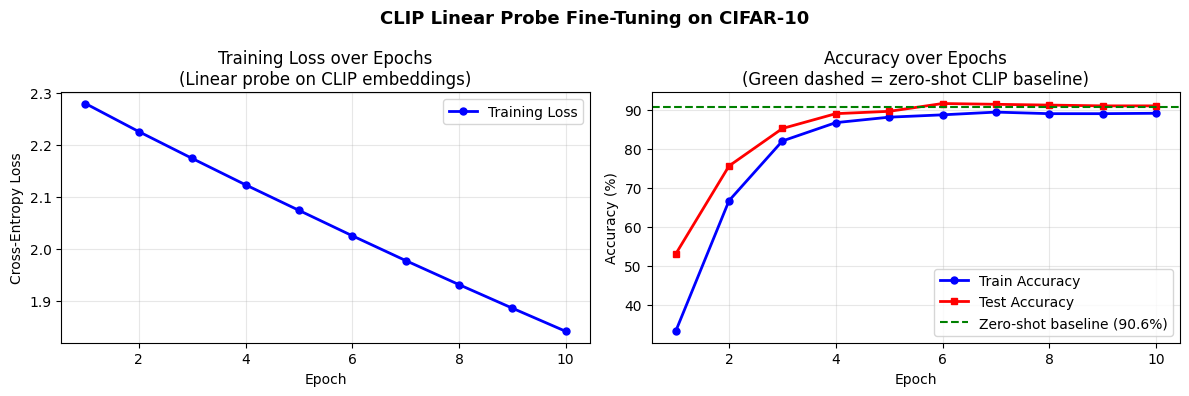

In [16]:
# ── Plot training curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

# Loss curve
ax1.plot(epochs_range, history['train_loss'], 'b-o', linewidth=2,
         markersize=5, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss over Epochs\n(Linear probe on CLIP embeddings)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, history['train_acc'], 'b-o', linewidth=2,
         markersize=5, label='Train Accuracy')
ax2.plot(epochs_range, history['test_acc'],  'r-s', linewidth=2,
         markersize=5, label='Test Accuracy')
ax2.axhline(y=overall_acc, color='green', linestyle='--', linewidth=1.5,
            label=f'Zero-shot baseline ({overall_acc:.1f}%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy over Epochs\n(Green dashed = zero-shot CLIP baseline)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CLIP Linear Probe Fine-Tuning on CIFAR-10',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clip_finetuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.1 — Few-Shot Learning Curve: Linear Probe Accuracy vs. K

In [17]:
# ── K-shot sweep: linear probe accuracy vs. number of shots per class ───────────
K_VALUES = [1, 5, 10, 50, 100]
sweep_results = {}

def build_shot_subset(k):
    """Return image indices with exactly k images per class."""
    indices = []
    seen = {c: 0 for c in range(10)}
    for idx, (_, label) in enumerate(cifar_train):
        if seen[label] < k:
            indices.append(idx)
            seen[label] += 1
        if all(v == k for v in seen.values()):
            break
    return indices

def extract_embeddings(indices):
    subset = Subset(cifar_train, indices)
    embeds, labels = [], []
    clip_model.eval()
    with torch.no_grad():
        for img_tensor, label in subset:
            pil_img = transforms.ToPILImage()(img_tensor)
            inp = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
            feat = clip_model.encode_image(inp)
            feat = feat / feat.norm(dim=-1, keepdim=True)
            embeds.append(feat.cpu())
            labels.append(label)
    return torch.cat(embeds, dim=0).to(torch.float32), torch.tensor(labels)

def train_probe(X_tr, y_tr, epochs=10, lr=1e-3, batch_size=64):
    probe = LinearProbe().to(DEVICE)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    train_loader = DataLoader(
        torch.utils.data.TensorDataset(X_tr.to(DEVICE), y_tr.to(DEVICE)),
        batch_size=batch_size, shuffle=True
    )
    for epoch in range(epochs):
        probe.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(probe(batch_x), batch_y)
            loss.backward()
            optimizer.step()
    return probe

def eval_probe(probe, X_te, y_te):
    probe.eval()
    with torch.no_grad():
        preds = probe(X_te.to(DEVICE)).argmax(dim=1).cpu()
    return (preds == y_te).float().mean().item() * 100

print(f"{'K (shots/class)':>16} {'Train imgs':>11} {'Test Acc':>10}")
print("-" * 42)
for k in K_VALUES:
    idx = build_shot_subset(k)
    X_k, y_k = extract_embeddings(idx)
    probe_k = train_probe(X_k, y_k)
    acc_k = eval_probe(probe_k, X_test, y_test)
    sweep_results[k] = acc_k
    print(f"{k:>16} {len(idx):>11} {acc_k:>9.1f}%")

print("-" * 42)
print(f"{'zero-shot (K=0)':>16} {'':>11} {overall_acc:>9.1f}%")

 K (shots/class)  Train imgs   Test Acc
------------------------------------------
               1          10      28.8%
               5          50      47.2%
              10         100      63.4%
              50         500      90.6%
             100        1000      90.6%
------------------------------------------
 zero-shot (K=0)                  90.6%


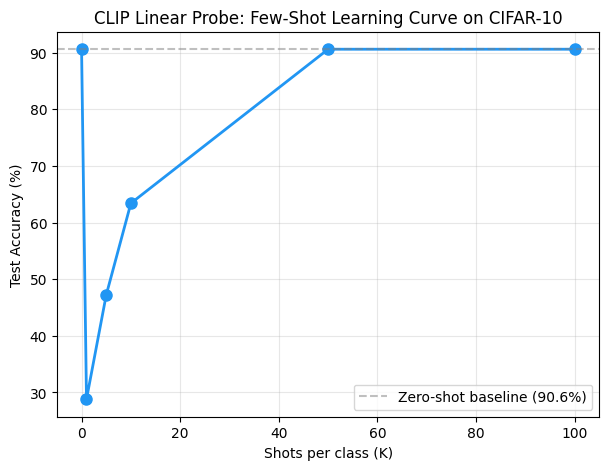

In [18]:
# ── Plot the few-shot learning curve ───────────────────────────────────
plt.figure(figsize=(7, 5))
ks_plot = [0] + K_VALUES
accs_plot = [overall_acc] + [sweep_results[k] for k in K_VALUES]
plt.plot(ks_plot, accs_plot, 'o-', linewidth=2, markersize=8, color='#2196F3')
plt.axhline(overall_acc, color='gray', linestyle='--', alpha=0.5, label=f'Zero-shot baseline ({overall_acc:.1f}%)')
plt.xlabel('Shots per class (K)')
plt.ylabel('Test Accuracy (%)')
plt.title('CLIP Linear Probe: Few-Shot Learning Curve on CIFAR-10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('few_shot_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
# SECTION 4: Summary and Key Takeaways

Run this cell to get a clean printed summary of everything we did.

In [19]:
# ── Final Summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("  CLIP + BLIP DEMO — SUMMARY")
print("=" * 60)

print("\n📌 CLIP (Radford et al., OpenAI 2021)")
print(f"   Model          : ViT-B/32")
print(f"   Embedding dim  : 512")
print(f"   Zero-shot acc  : {overall_acc:.1f}% on CIFAR-10 (no training!)")
print(f"   After 10 epochs linear probe: {test_acc:.1f}%")
print(f"   Random baseline: 10.0%")

print("\n📌 BLIP (Li et al., Salesforce 2022)")
print("   Model          : blip-image-captioning-base")
print("   Generated captions for CIFAR-10 images (zero-shot)")
print("   Scored image-text match probability (ITM)")

print("\n📌 Key ideas demonstrated:")
print("   1. Zero-shot classification: classify without training on target classes")
print("   2. Embedding space: images + text in the same 512-dim vector space")
print("   3. t-SNE: visualise high-dimensional embeddings in 2D")
print("   4. Text-to-image retrieval: find images matching a text query")
print("   5. Image captioning: BLIP generates natural language for images")
print("   6. Fine-tuning: linear probe improves over zero-shot baseline")

print("\n📌 Connection to Few-Shot Learning (your research):")
print("   CLIP is a zero-shot learner — extreme case of FSL (K=0)")
print("   Linear probe with 100 samples/class → few-shot regime")
print("   BLIP's bootstrapping = a form of self-supervised prior knowledge")
print("   Both models show: prior knowledge from large-scale pre-training")
print("   compensates for lack of labeled examples — the core FSL idea.")

print("\n" + "=" * 60)

  CLIP + BLIP DEMO — SUMMARY

📌 CLIP (Radford et al., OpenAI 2021)
   Model          : ViT-B/32
   Embedding dim  : 512
   Zero-shot acc  : 90.6% on CIFAR-10 (no training!)
   After 10 epochs linear probe: 91.0%
   Random baseline: 10.0%

📌 BLIP (Li et al., Salesforce 2022)
   Model          : blip-image-captioning-base
   Generated captions for CIFAR-10 images (zero-shot)
   Scored image-text match probability (ITM)

📌 Key ideas demonstrated:
   1. Zero-shot classification: classify without training on target classes
   2. Embedding space: images + text in the same 512-dim vector space
   3. t-SNE: visualise high-dimensional embeddings in 2D
   4. Text-to-image retrieval: find images matching a text query
   5. Image captioning: BLIP generates natural language for images
   6. Fine-tuning: linear probe improves over zero-shot baseline

📌 Connection to Few-Shot Learning (your research):
   CLIP is a zero-shot learner — extreme case of FSL (K=0)
   Linear probe with 100 samples/class → 